In [77]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
# 한글 폰트 설정 
plt.rcParams['axes.unicode_minus'] = False

In [78]:
# Step 0: 하이퍼파라미터 설정
# ============================================================================

BATCH_SIZE = 32
NUM_EPOCHS = 30
ALPHA = 0.3
K_FOLDS = 5
RANDOM_STATE = 42

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Device: {device}")

✓ Device: cuda


In [79]:
# Step 1: 데이터 로드
# ============================================================================

train_csv = pd.read_csv('train.csv')
meta_csv = pd.read_csv('meta.csv')

print(f"✓ Train 데이터: {len(train_csv)}장")
print(f"✓ 총 클래스: {len(meta_csv)}개")

✓ Train 데이터: 1570장
✓ 총 클래스: 17개


In [80]:
meta_csv

,target,class_name
0,0,account_number
1,1,application_for_payment_of_pregnancy_medical_e...
2,2,car_dashboard
3,3,confirmation_of_admission_and_discharge
4,4,diagnosis
5,5,driver_lisence
6,6,medical_bill_receipts
7,7,medical_outpatient_certificate
8,8,national_id_card
9,9,passport


In [81]:
# Step 2: Semantic Grouping
# ============================================================================

class_group_mapping = {
    'account_number': 'other',
    'application_for_payment_of_pregnancy_medical_expenses': 'medical',
    'car_dashboard': 'vehicle',
    'confirmation_of_admission_and_discharge': 'medical',
    'diagnosis': 'medical',
    'driver_lisence': 'identity',
    'medical_bill_receipts': 'medical',
    'medical_outpatient_certificate': 'medical',
    'national_id_card': 'identity',
    'passport': 'identity',
    'payment_confirmation': 'medical',
    'pharmaceutical_receipt': 'medical',
    'prescription': 'medical',
    'resume': 'document',
    'statement_of_opinion': 'document',
    'vehicle_registration_certificate': 'vehicle',
    'vehicle_registration_plate': 'vehicle',
}

group_to_idx = {'medical': 0, 'identity': 1, 'vehicle': 2, 'document': 3, 'other': 4}

train_csv['class_name'] = train_csv['target'].map(lambda x: meta_csv.iloc[x]['class_name'])
train_csv['group'] = train_csv['class_name'].map(class_group_mapping)
train_csv['group_idx'] = train_csv['group'].map(group_to_idx)

print(f"✓ Semantic Grouping 완료!")


✓ Semantic Grouping 완료!


In [82]:
# Step 3: Augmentation 정의
# ============================================================================

train_transform = A.Compose([
    A.Resize(224, 224),
    A.Rotate(limit=180, p=0.8),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.GaussNoise(p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.4),
    # ✅ 강화된 Augmentation 추가!
    A.Blur(blur_limit=3, p=0.2),
    A.ImageCompression(quality_lower=85, p=0.2),
    A.Normalize(),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(),
    ToTensorV2(),
])

test_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(),
    ToTensorV2(),
])

print(f"✓ 강화된 Augmentation 정의 완료!")


✓ 강화된 Augmentation 정의 완료!


In [83]:
# Step 4: Dataset 클래스 정의 (중요!)
# ============================================================================

class DocumentDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_name = row['ID']
        img_path = os.path.join(self.image_dir, img_name)
        
        try:
            image = Image.open(img_path).convert('RGB')
        except:
            image = Image.new('RGB', (224, 224))
        
        image = np.array(image)
        
        if self.transform:
            image = self.transform(image=image)['image']
        
        return {
            'image': image,
            'target': torch.tensor(int(row['target']), dtype=torch.long),
            'group_idx': torch.tensor(int(row['group_idx']), dtype=torch.long),
            'img_name': img_name
        }

class TestDocumentDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_name = row['ID']
        img_path = os.path.join(self.image_dir, img_name)
        
        try:
            image = Image.open(img_path).convert('RGB')
        except:
            image = Image.new('RGB', (224, 224))
        
        image = np.array(image)
        
        if self.transform:
            image = self.transform(image=image)['image']
        
        return {'image': image, 'img_name': img_name}

print(f"✓ Dataset 클래스 정의 완료!")

✓ Dataset 클래스 정의 완료!


In [84]:
# Step 5: Hierarchical Model 정의
# ============================================================================

class HierarchicalDocumentClassifier(nn.Module):
    def __init__(self, num_groups=5, num_classes=17):
        super().__init__()
        
        self.backbone = timm.create_model('efficientnet_b3', pretrained=True, num_classes=0)
        self.feature_dim = 1536
        
        self.group_head = nn.Sequential(
            nn.Linear(self.feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_groups)
        )
        
        self.fine_heads = nn.ModuleDict({
            'medical': nn.Linear(self.feature_dim, 8),
            'identity': nn.Linear(self.feature_dim, 3),
            'vehicle': nn.Linear(self.feature_dim, 3),
            'document': nn.Linear(self.feature_dim, 2),
            'other': nn.Linear(self.feature_dim, 1),
        })
        
        self.group_names = ['medical', 'identity', 'vehicle', 'document', 'other']
    
    def forward(self, x):
        features = self.backbone(x)
        group_logits = self.group_head(features)
        
        fine_logits_list = [self.fine_heads[name](features) for name in self.group_names]
        fine_logits = torch.cat(fine_logits_list, dim=1)
        
        return group_logits, fine_logits

print(f"✓ Model 정의 완료!")


✓ Model 정의 완료!


In [85]:
# Step 6: Loss & 학습 함수
# ============================================================================

def hierarchical_loss(group_logits, fine_logits, group_labels, fine_labels, alpha=0.3):
    group_loss = nn.functional.cross_entropy(group_logits, group_labels)
    fine_loss = nn.functional.cross_entropy(fine_logits, fine_labels)
    return alpha * group_loss + (1 - alpha) * fine_loss, group_loss, fine_loss

def train_one_epoch(loader, model, optimizer, device, alpha=0.3):
    model.train()
    total_loss = 0
    
    pbar = tqdm(loader, desc="Training", ncols=100)
    
    for batch in pbar:
        images = batch['image'].to(device)
        group_labels = batch['group_idx'].to(device)
        fine_labels = batch['target'].to(device)
        
        optimizer.zero_grad()
        group_logits, fine_logits = model(images)
        
        loss, _, _ = hierarchical_loss(group_logits, fine_logits, group_labels, fine_labels, alpha=alpha)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return {'loss': total_loss / len(loader)}

def evaluate(loader, model, device):
    model.eval()
    fine_preds, fine_targets = [], []
    
    with torch.no_grad():
        pbar = tqdm(loader, desc="Evaluating", ncols=100)
        
        for batch in pbar:
            images = batch['image'].to(device)
            fine_labels = batch['target'].to(device)
            
            _, fine_logits = model(images)
            
            fine_preds.extend(torch.argmax(fine_logits, dim=1).cpu().numpy())
            fine_targets.extend(fine_labels.cpu().numpy())
    
    fine_f1 = f1_score(fine_targets, fine_preds, average='macro', zero_division=0)
    
    return {'fine_f1': fine_f1}

print(f"✓ Loss & 함수 정의 완료!")

✓ Loss & 함수 정의 완료!


In [86]:
# Step 7: K-Fold 설정
# ============================================================================

K_FOLDS = 5
NUM_EPOCHS = 30
kfold = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
fold_indices = list(kfold.split(train_csv))

print(f"✓ K-Fold 설정 완료!")

# ============================================================================
# Step 8: K-Fold 학습 루프
# ============================================================================

print("\n" + "="*60)
print("="*60)

fold_results = []
all_fold_models = []

for fold, (train_idx, val_idx) in enumerate(fold_indices):
    print(f"\n[Fold {fold+1}/{K_FOLDS}]")
    
    train_fold = train_csv.iloc[train_idx].reset_index(drop=True)
    val_fold = train_csv.iloc[val_idx].reset_index(drop=True)
    
    train_fold_dataset = DocumentDataset(train_fold, 'train/', transform=train_transform)
    val_fold_dataset = DocumentDataset(val_fold, 'train/', transform=val_transform)
    
    train_fold_loader = DataLoader(train_fold_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
    val_fold_loader = DataLoader(val_fold_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
    
    fold_model = HierarchicalDocumentClassifier(num_groups=5, num_classes=17)
    fold_model = fold_model.to(device)
    fold_model.eval()
    
    fold_optimizer = torch.optim.AdamW(fold_model.parameters(), lr=1e-4, weight_decay=1e-4)
    fold_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(fold_optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
    
    best_fold_f1 = 0
    best_fold_model_path = f'best_fold_{fold+1}_model.pth'
    
    for epoch in range(NUM_EPOCHS):
        train_metrics = train_one_epoch(train_fold_loader, fold_model, fold_optimizer, device, alpha=ALPHA)
        val_metrics = evaluate(val_fold_loader, fold_model, device)
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"[Epoch {epoch+1:2d}] Train Loss: {train_metrics['loss']:.4f} | Val F1: {val_metrics['fine_f1']:.4f}")
        
        if val_metrics['fine_f1'] > best_fold_f1:
            best_fold_f1 = val_metrics['fine_f1']
            torch.save(fold_model.state_dict(), best_fold_model_path)
        
        fold_scheduler.step()
    
    fold_results.append(best_fold_f1)
    all_fold_models.append(best_fold_model_path)
    
    print(f"✅ Fold {fold+1} 완료 | Best F1: {best_fold_f1:.4f}")

print(f"\n{'='*60}")
print(f"✅ K-Fold 학습 완료!")
print(f"{'='*60}")
print(f"\n📊 결과: 평균 F1 = {np.mean(fold_results):.4f}")


✓ K-Fold 설정 완료!


[Fold 1/5]


Evaluating: 100%|███████████████████████████████████████████████████| 10/10 [00:02<00:00,  3.86it/s]


[Epoch  1] Train Loss: 2.1417 | Val F1: 0.5515


Evaluating: 100%|███████████████████████████████████████████████████| 10/10 [00:02<00:00,  3.86it/s]


[Epoch  5] Train Loss: 0.3685 | Val F1: 0.8170


...

[Epoch 20] Train Loss: 0.0925 | Val F1: 0.8752


Evaluating: 100%|███████████████████████████████████████████████████| 10/10 [00:02<00:00,  3.90it/s]


[Epoch 25] Train Loss: 0.0702 | Val F1: 0.8843


Evaluating: 100%|███████████████████████████████████████████████████| 10/10 [00:02<00:00,  3.86it/s]


[Epoch 30] Train Loss: 0.0707 | Val F1: 0.8959
✅ Fold 5 완료 | Best F1: 0.8959

✅ K-Fold 학습 완료!

📊 결과: 평균 F1 = 0.9028


In [87]:
# Step 9: Ensemble Inference
# ============================================================================

print("\n" + "="*60)
print("Step 9: Ensemble Inference")
print("="*60)

print("\n1️⃣  모든 Fold 모델 로드")
ensemble_models = []

for fold in range(K_FOLDS):
    fold_model = HierarchicalDocumentClassifier(num_groups=5, num_classes=17)
    fold_model_path = f'best_fold_{fold+1}_model.pth'
    fold_model.load_state_dict(torch.load(fold_model_path, map_location=device))
    fold_model = fold_model.to(device)
    fold_model.eval()
    ensemble_models.append(fold_model)

print(f"✓ 총 {K_FOLDS}개 모델 로드 완료")

print("\n2️⃣  Test 데이터 준비")
test_files = sorted(os.listdir('test/'))
test_dataframe = pd.DataFrame({'ID': test_files, 'target': 0, 'group_idx': 0})

test_dataset = TestDocumentDataset(test_dataframe, 'test/', transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"✓ Test 데이터: {len(test_dataframe)}장")

print("\n3️⃣  앙상블 추론")
all_ensemble_logits = []
all_img_names = []

with torch.no_grad():
    pbar = tqdm(test_loader, desc="Ensemble Inference", ncols=100)
    
    for batch in pbar:
        images = batch['image'].to(device)
        img_names = batch['img_name']
        
        batch_logits = []
        for fold_model in ensemble_models:
            _, fine_logits = fold_model(images)
            batch_logits.append(fine_logits.cpu().numpy())
        
        ensemble_logit = np.mean(batch_logits, axis=0)
        all_ensemble_logits.append(ensemble_logit)
        all_img_names.extend(img_names)

print(f"✓ 추론 완료")

print("\n4️⃣  최종 예측 및 파일 생성")
all_ensemble_logits = np.concatenate(all_ensemble_logits, axis=0)
all_predictions = np.argmax(all_ensemble_logits, axis=1)

submission_df = pd.DataFrame({'ID': all_img_names, 'target': all_predictions})
submission_path = 'submission_aug_6_to_8.csv'
submission_df.to_csv(submission_path, index=False)

print(f"✓ 제출 파일 저장: {submission_path}")
print(submission_df.head())

print(f"\n{'='*60}")
print(f"✅ 완료! 제출 파일: {submission_path}")
print(f"{'='*60}")


Step 9: Ensemble Inference

1️⃣  모든 Fold 모델 로드
✓ 총 5개 모델 로드 완료

2️⃣  Test 데이터 준비
✓ Test 데이터: 3140장

3️⃣  앙상블 추론


Ensemble Inference: 100%|███████████████████████████████████████████| 99/99 [00:29<00:00,  3.34it/s]

✓ 추론 완료

4️⃣  최종 예측 및 파일 생성
✓ 제출 파일 저장: submission_aug_6_to_8.csv
                     ID  target
0  0008fdb22ddce0ce.jpg       2
1  00091bffdffd83de.jpg      12
2  00396fbc1f6cc21d.jpg       5
3  00471f8038d9c4b6.jpg       3
4  00901f504008d884.jpg       2

✅ 완료! 제출 파일: submission_aug_6_to_8.csv


# 시각화 해보기

✅ Visualization ready...
✅ Graph saved: fold_results.png


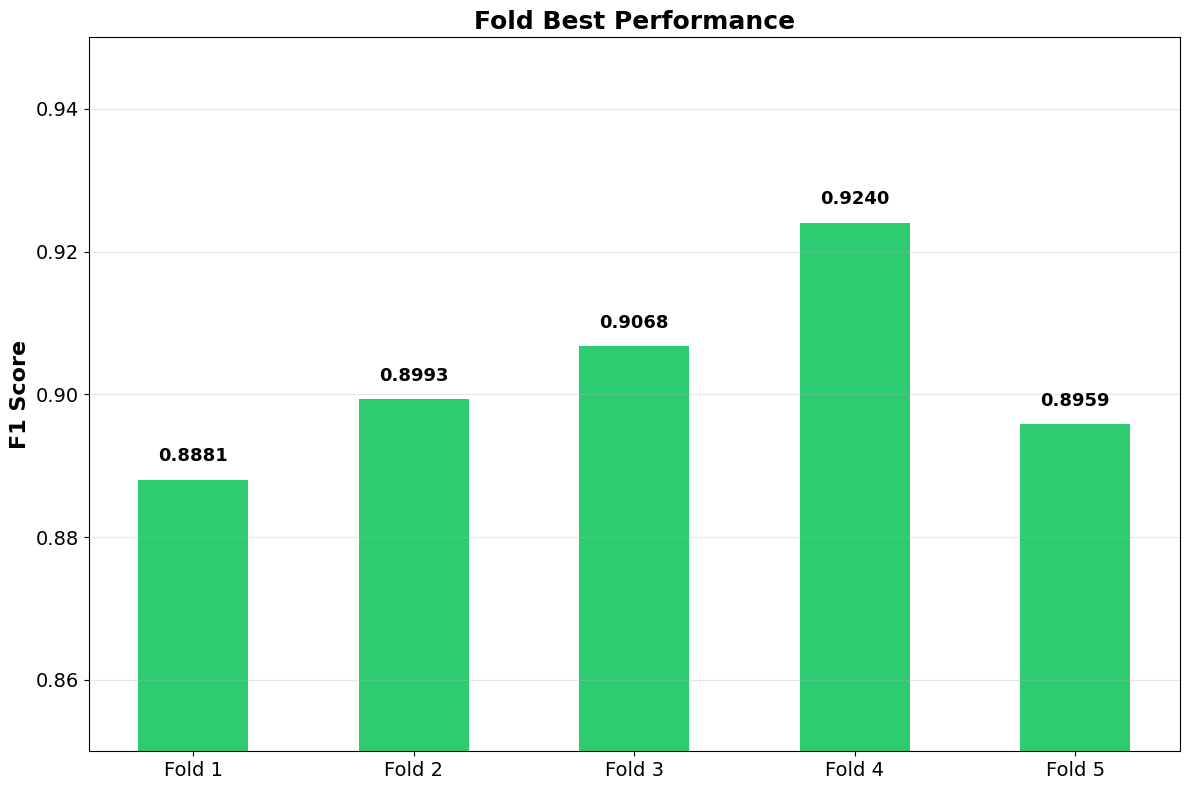


Final Results:
Mean F1 Score: 0.9028
Min F1 Score:  0.8881
Max F1 Score:  0.9240


In [88]:
import matplotlib.pyplot as plt
import numpy as np

print(f"✅ Visualization ready...")

fold_names = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']
best_f1s = fold_results

plt.figure(figsize=(12, 8))
colors = ['#2ecc71' if f > 0.88 else '#3498db' for f in best_f1s]
plt.bar(fold_names, best_f1s, color=colors, width=0.5)

plt.ylabel('F1 Score', fontsize=16, fontweight='bold')
plt.title('Fold Best Performance', fontsize=18, fontweight='bold')
plt.ylim([0.85, 0.95])  # ✅ 0.91 → 0.92 (더 넓게!)

plt.yticks(fontsize=14)
plt.xticks(fontsize=14)

for i, v in enumerate(best_f1s):
    plt.text(i, v + 0.002, f'{v:.4f}', ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('fold_results.png', dpi=150, bbox_inches='tight')
print("✅ Graph saved: fold_results.png")
plt.show()

print(f"\n{'='*60}")
print(f"Final Results:")
print(f"{'='*60}")
print(f"Mean F1 Score: {np.mean(best_f1s):.4f}")
print(f"Min F1 Score:  {np.min(best_f1s):.4f}")
print(f"Max F1 Score:  {np.max(best_f1s):.4f}")
print(f"{'='*60}")


Groups found: ['document', 'identity', 'medical', 'other', 'vehicle']

🎯 Group document: 3 samples


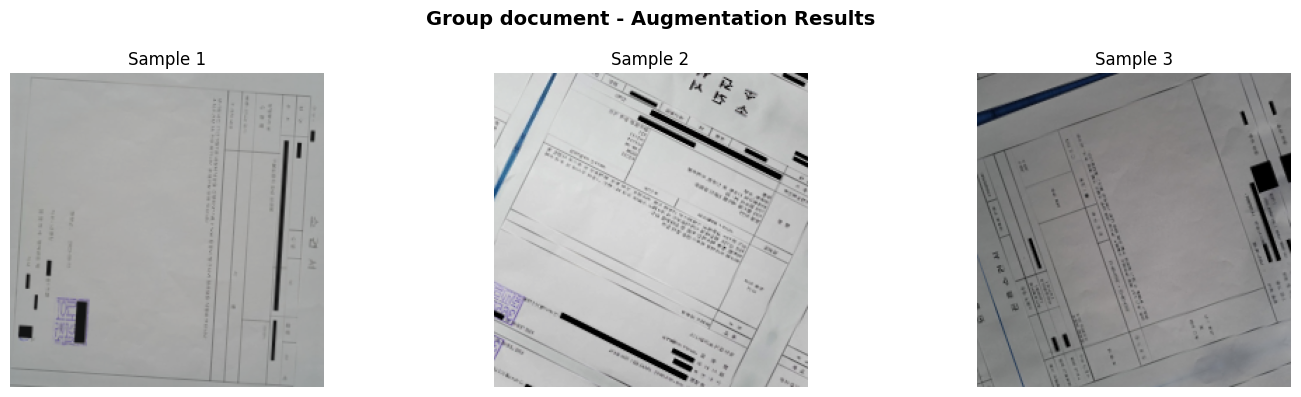


🎯 Group identity: 3 samples


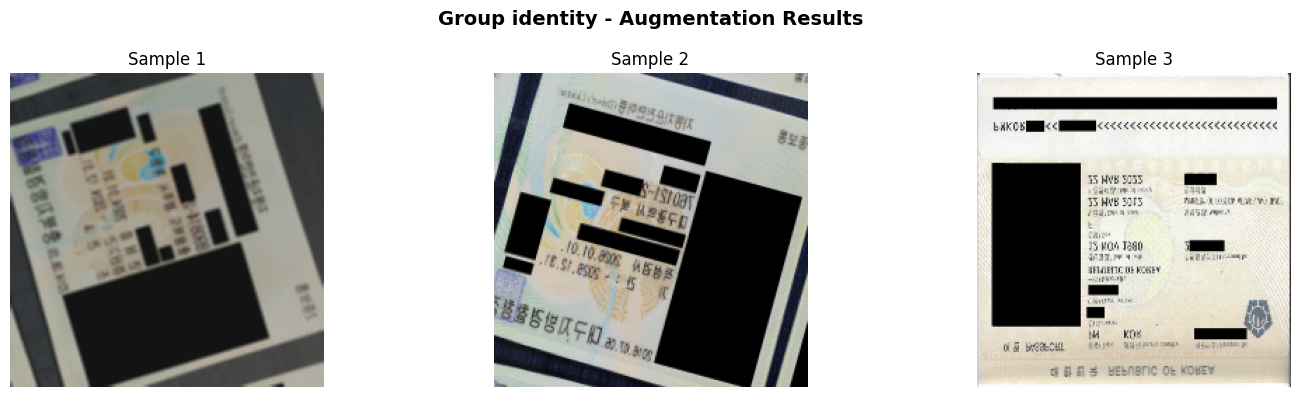


🎯 Group medical: 3 samples


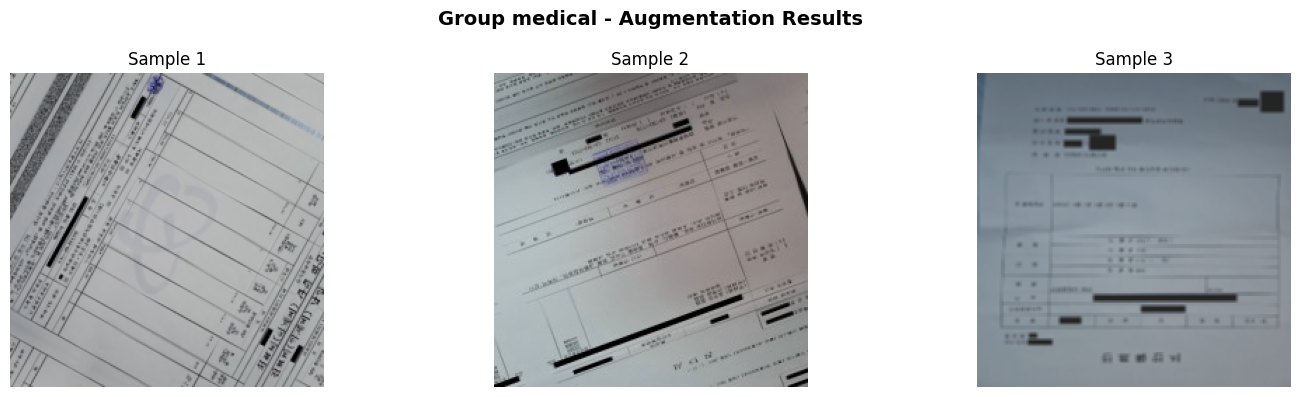


🎯 Group other: 3 samples


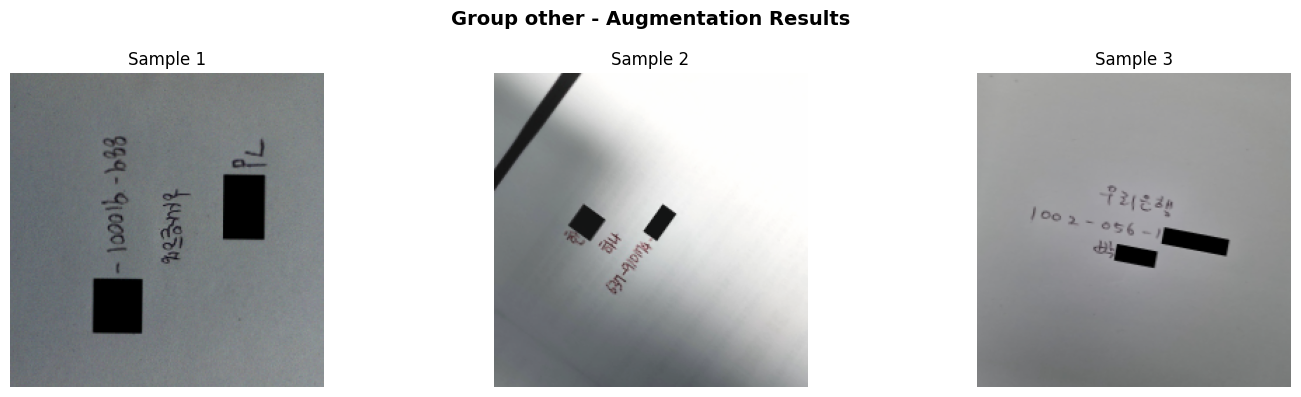


🎯 Group vehicle: 3 samples


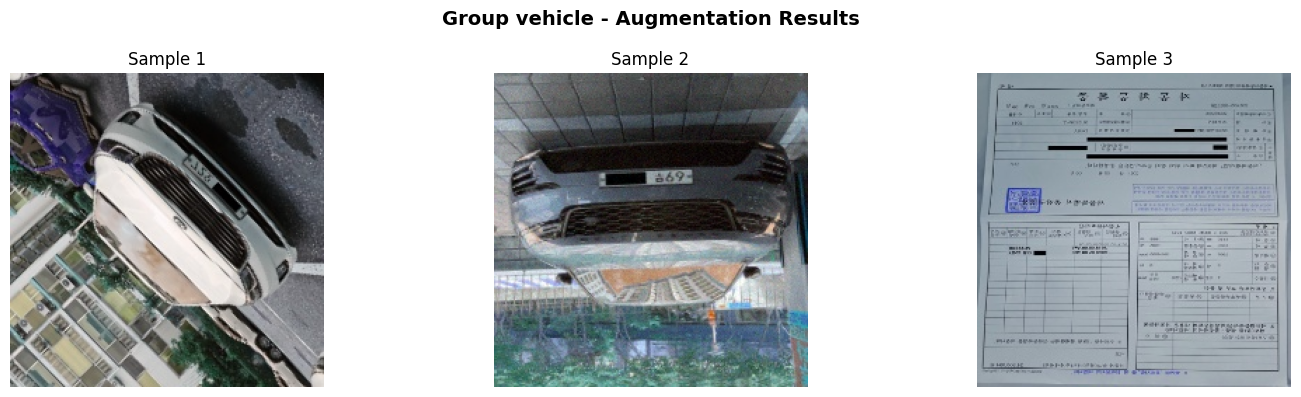


✅ Visualization complete!


In [89]:
def denormalize_correct(image):
    """✅ 올바른 역정규화"""
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    # Tensor → numpy
    if torch.is_tensor(image):
        img_np = image.detach().cpu().numpy()
    else:
        img_np = image
    
    # C, H, W → H, W, C
    if img_np.ndim == 3 and img_np.shape[0] == 3:
        img_np = img_np.transpose(1, 2, 0)
    
    # ✅ 역정규화: image * std + mean
    img_denorm = img_np * std + mean
    
    return np.clip(img_denorm, 0, 1)


def show_group_augmentation_simple(train_fold_dataset, train_fold, num_per_group=3):
    """
    각 그룹별 이미지 시각화 (올바른 역정규화)
    """
    
    groups = sorted(train_fold['group'].unique())
    print(f"Groups found: {groups}")
    
    for group in groups:
        # 이 그룹에 속한 인덱스
        group_indices = train_fold[train_fold['group'] == group].index.tolist()[:num_per_group]
        
        print(f"\n🎯 Group {group}: {len(group_indices)} samples")
        
        if len(group_indices) == 0:
            continue
        
        fig, axes = plt.subplots(1, len(group_indices), figsize=(15, 4))
        
        # ✅ axes가 배열이 아니라 단일 객체인 경우 처리
        if len(group_indices) == 1:
            axes = [axes]
        
        for idx, sample_idx in enumerate(group_indices):
            try:
                # 데이터 로드
                sample_data = train_fold_dataset[sample_idx]
                
                image = None
                
                # ✅ 다양한 형식 지원
                if isinstance(sample_data, (list, tuple)):
                    image = sample_data[0]
                elif isinstance(sample_data, dict):
                    image = sample_data.get('image', None)
                else:
                    image = sample_data
                
                if image is None:
                    print(f"   Warning: No image for sample {sample_idx}")
                    continue
                
                # ✅ 타입 체크: str(type) 사용
                type_str = str(type(image))
                
                # Tensor 확인
                if 'torch' in type_str or 'Tensor' in type_str:
                    # ✅ GPU → CPU 변환
                    if hasattr(image, 'is_cuda') and image.is_cuda:
                        image = image.cpu()
                    
                    # ✅ 올바른 역정규화 사용!
                    image_display = denormalize_correct(image)
                else:
                    image_display = image
                
                axes[idx].imshow(image_display)
                axes[idx].set_title(f'Sample {idx+1}', fontsize=12)
                axes[idx].axis('off')
                
            except Exception as e:
                print(f"   Error loading sample {sample_idx}: {type(e).__name__}: {e}")
        
        plt.suptitle(f'Group {group} - Augmentation Results', fontsize=14, fontweight='bold')
        plt.tight_layout()
        #plt.savefig(f'group_{group}_augmentation.png', dpi=150, bbox_inches='tight')
        plt.show()
        
    print("\n✅ Visualization complete!")

# ✅ 실행!
show_group_augmentation_simple(train_fold_dataset, train_fold, num_per_group=3)

